In [46]:
import pandas as pd
import numpy as np
import tanalysis.traj_analysis as ta
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [2]:
dirname = r"C:\Users\pcanaleta\Documents\Cellpose_segmentation\EXP.HD6.Chips\EXP.HD6.1.1.MatekChips_CXCL10\24h\Tracks\excel_tracks\CXCL10_Conc10.xlsx"
savedir = r"C:\Users\pcanaleta\Documents\Cellpose_segmentation\EXP.HD6.Chips\EXP.HD6.1.1.MatekChips_CXCL10\24h\Tracks\excel_tracks\Results"
filter_values = {'track_duration':(0,200000), 'mean_velocity':(0,100), 'total_distance':(0,100000)}
tracks, names = ta.crop_traj(dirname, filter_tracks=False, filter_values=filter_values)

In [3]:
ta.turning_angle(tracks, names, 's', savedir, True)

,id,total_turning_angle,persistence
0,0,1587.571161,0.308608
1,1,1398.725608,0.436350
2,2,2399.939004,0.181057
3,3,1113.562556,0.564124
4,4,1350.702061,0.468469
5,5,1583.705465,0.281143
6,6,1584.834167,0.315904
7,7,1414.620647,0.361094
8,8,913.501990,0.688345
9,9,1405.378339,0.367701


[4.96227845e+02 9.97319863e-02 9.06277883e-09] [5.11275865e-03 1.33514952e+01 1.00000000e+01]
[4.26804100e+02 1.59563571e-01 3.62517407e-07] [3.91319915e-03 2.18602903e+01 1.00000000e+01]
[4.51545314 0.13679922 8.40035974] [1.86922325 0.04652749 6.4239123 ]
[9.99999997e+02 2.18664543e-01 2.01285220e-08] [2.92930913e-03 1.90241826e+01 1.00000000e+01]
[3.23938667e-03 5.25483584e+01 1.00000000e+01] [3.01311943e+02 1.29113869e-01 6.47472332e-09]
[4.43261509e+02 1.91246474e-01 2.32932263e-07] [1.00000000e+03 8.53481083e-02 4.86388689e-08]
[4.48463958e+02 1.62296053e-01 3.54097778e-10] [2.67612833e-03 2.36232191e+01 1.00000000e+01]
[5.6474183e-03 2.5107655e+01 1.0000000e+01] [3.17686640e-03 2.28580748e+01 1.00000000e+01]
[3.89459138e+02 2.42182638e-01 5.29236292e-08] [1.00000000e+03 8.09141296e-02 1.69821259e-07]
[5.15868230e+02 1.45040120e-01 3.91789693e-08] [1.00000000e+03 5.41910865e-02 6.18728847e-11]
[3.09138619e+02 1.29119328e-01 3.99829187e-08] [4.91082223e+02 4.70720742e-02 1.0000000

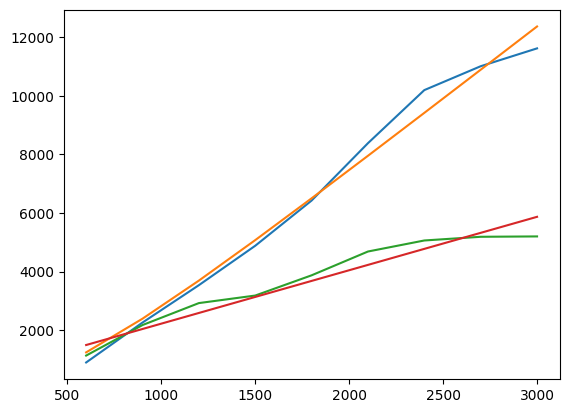

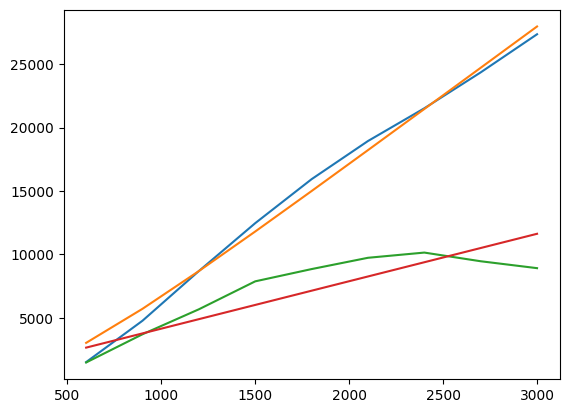

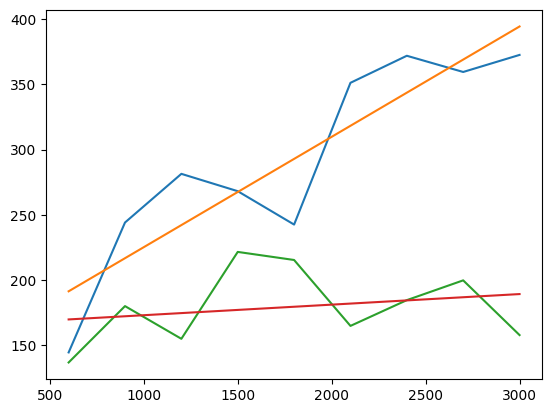

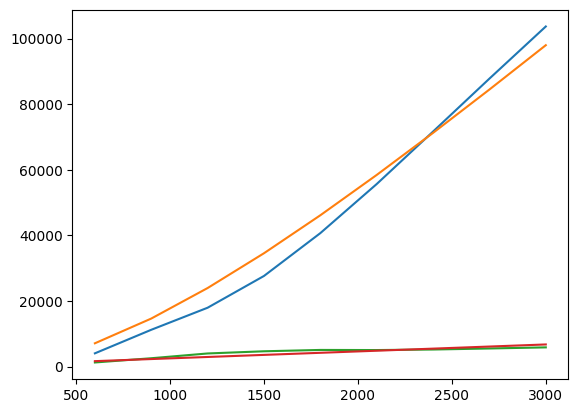

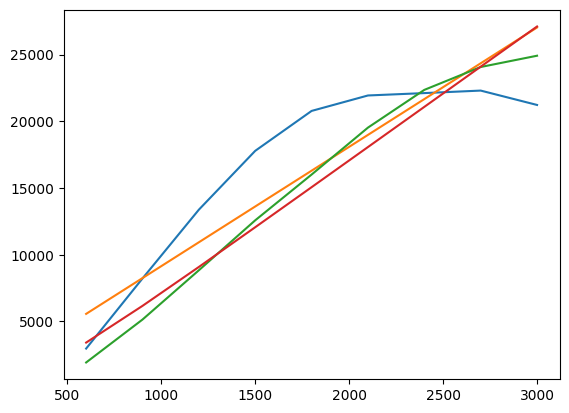

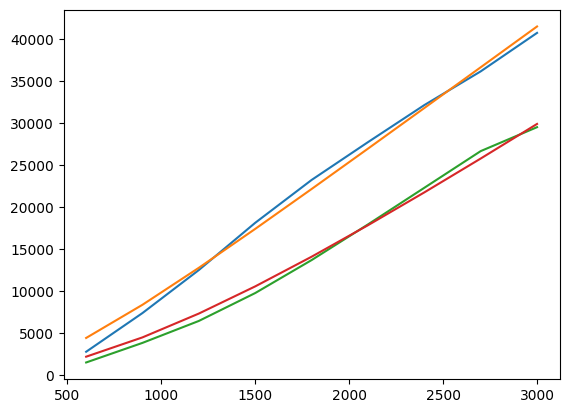

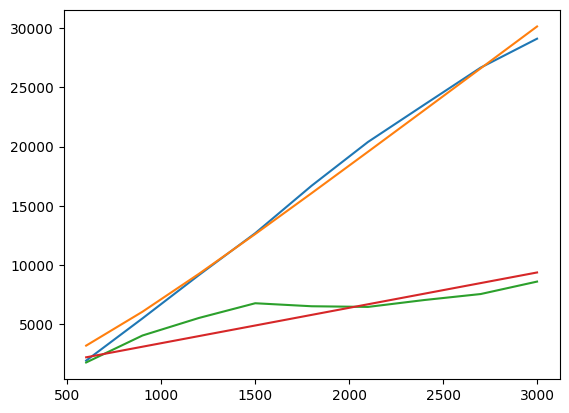

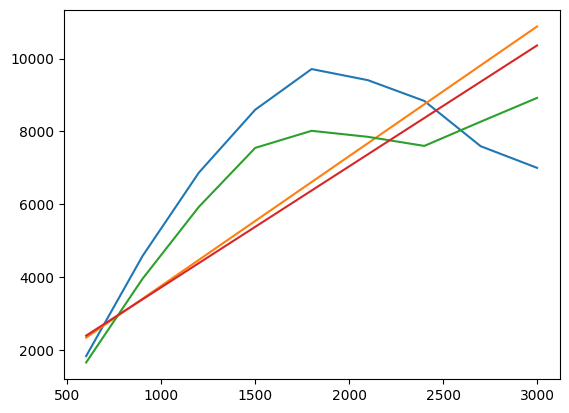

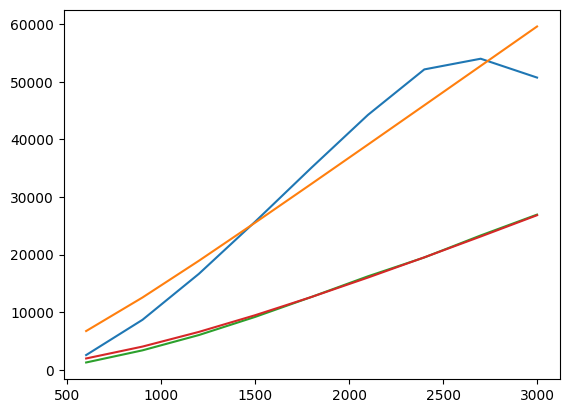

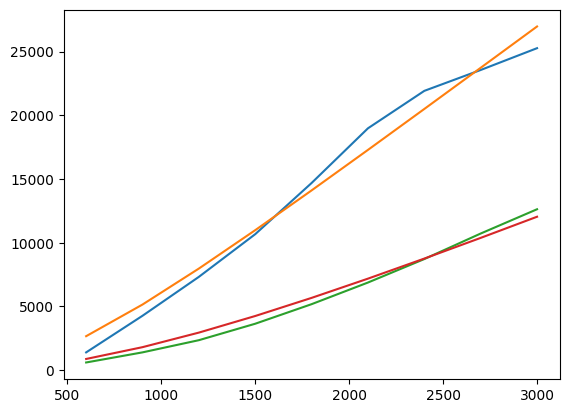

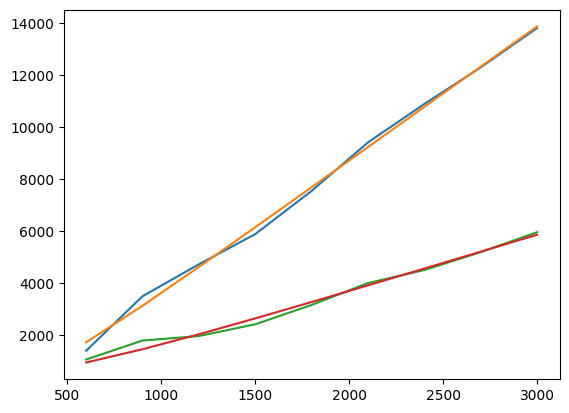

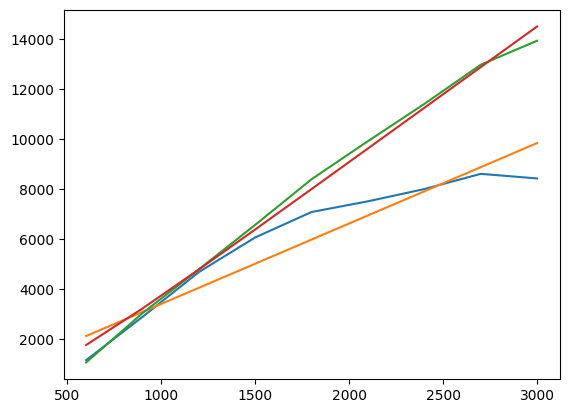

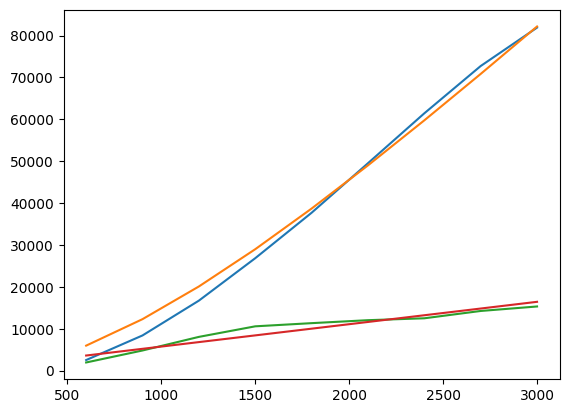

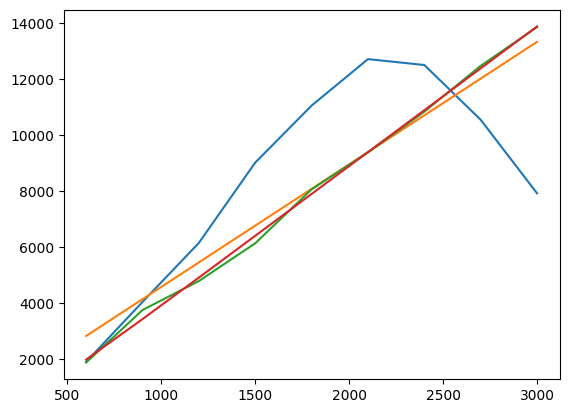

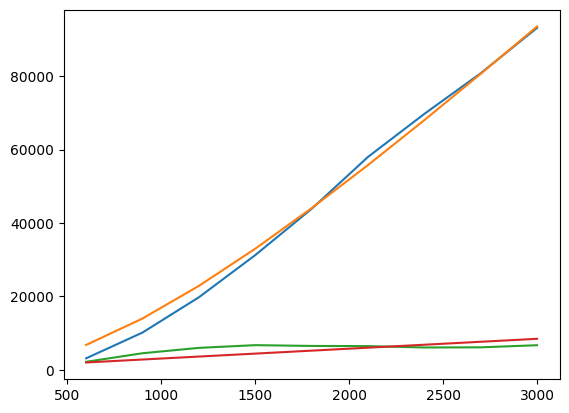

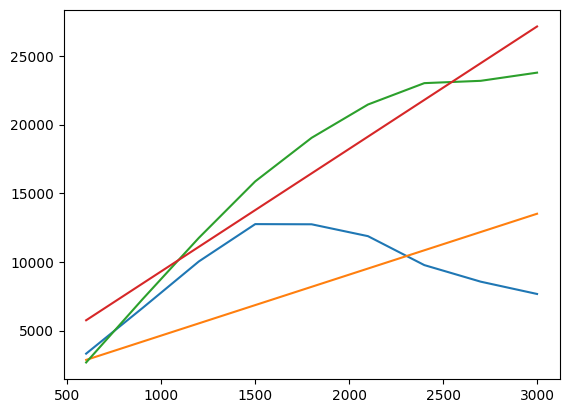

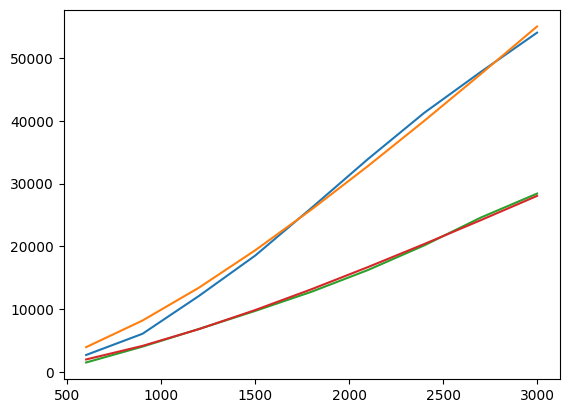

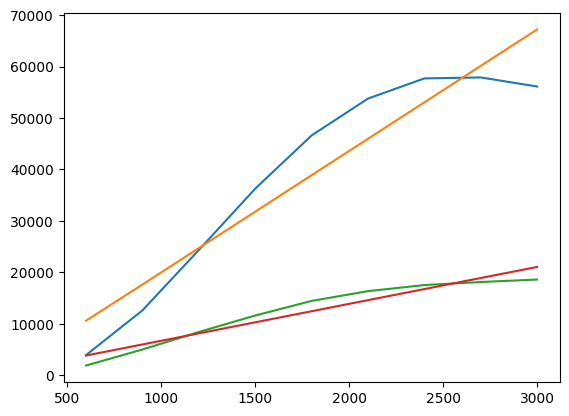

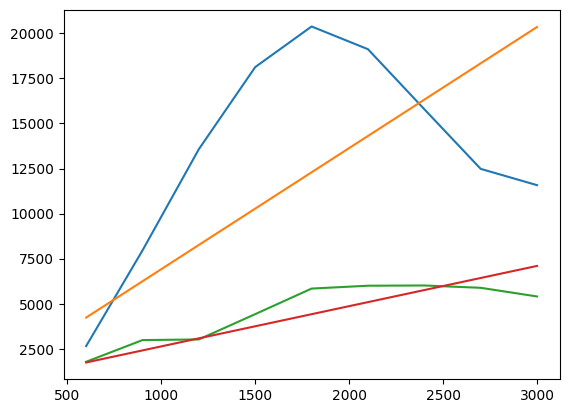

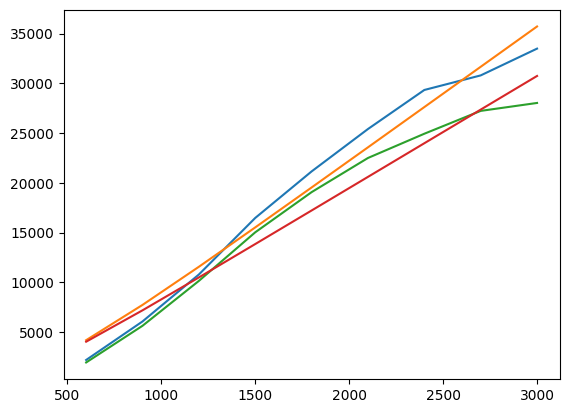

In [70]:
ids = np.unique(tracks.index.get_level_values(0))
for id in ids:
    track = tracks.loc[id]
    xyz = track.iloc[:,slice(1,None,1)].dropna()
    dxyz = np.diff(xyz, axis=0)
    U,S,V = np.linalg.svd(dxyz, full_matrices=False)
    xyzrot = xyz@V.T ######

    msdp0 = ta.ezmsd(xyzrot.iloc[:,0])
    msdnp0 = ta.ezmsd(xyzrot.iloc[:,1])
    if len(xyz.columns) == 3:
        msdnp0 += ta.ezmsd(xyzrot.iloc[:,2])
    
    t = np.arange(1,24,1)
    poptp, _ = curve_fit(ta.tPRW1D, t[1:10]*300, msdp0[:9], p0=(100,3,1), bounds=([0, 0, 0], [1000,1000,10]), method='trf', maxfev=10000)
    poptnp, _ = curve_fit(ta.tPRW2D, t[1:10]*300, msdnp0[:9], p0=(100,3,1), bounds=([0, 0, 0], [1000,1000,10]), method='trf', maxfev=10000)

    print(poptp, poptnp)

    plt.figure()
    plt.plot(t[1:10]*300, msdp0[:9])
    plt.plot(t[1:10]*300, ta.tPRW1D(t[1:10]*300, *poptp))
    plt.plot(t[1:10]*300, msdnp0[:9])
    plt.plot(t[1:10]*300, ta.tPRW2D(t[1:10]*300, *poptnp))

    